In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [293]:
df = pd.read_csv('cleaned_fitness_data.csv')

In [294]:
# dropping unnamed columns
df.drop(columns=["Unnamed: 6", "Unnamed: 7", "Unnamed: 8", "Unnamed: 9", "Unnamed: 10", "Unnamed: 11"], inplace=True)
df.head()

,Gender,Age,Height,Weight,Calories,BMI
0,male,66.9,191,94,231,25.72
1,female,21.6,166,60,66,21.75
2,female,33.0,178,70,71,21.96
3,female,25.2,155,57,37,23.92
4,female,34.8,150,50,124,22.28


In [295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11001 entries, 0 to 11000
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Gender    11001 non-null  object 
 1   Age       11001 non-null  float64
 2   Height    11001 non-null  int64  
 3   Weight    11001 non-null  int64  
 4   Calories  11001 non-null  int64  
 5   BMI       11001 non-null  float64
dtypes: float64(2), int64(3), object(1)
memory usage: 515.8+ KB


{'whiskers': [<matplotlib.lines.Line2D at 0x23c3187b110>,
 'caps': [<matplotlib.lines.Line2D at 0x23c3187b390>,
 'boxes': [<matplotlib.lines.Line2D at 0x23c3187afd0>],
 'medians': [<matplotlib.lines.Line2D at 0x23c3187b610>],
 'fliers': [<matplotlib.lines.Line2D at 0x23c3187b750>],
 'means': []}

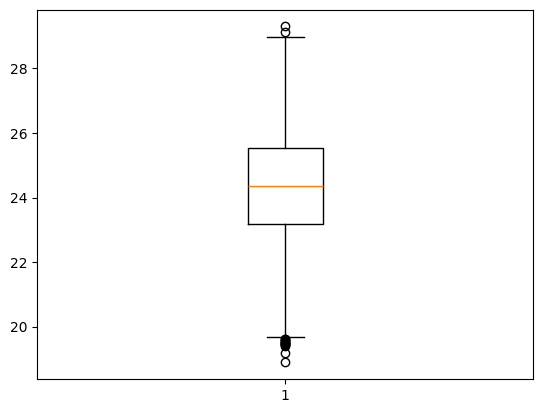

In [296]:
plt.boxplot(df['BMI'])

In [297]:
X = df.drop('BMI', axis=1)
y = df['BMI']

In [298]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

In [299]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=42)   

In [300]:
from yaml import compose


compose= ColumnTransformer(
    transformers=[
        ('onehotencoder', OneHotEncoder(handle_unknown='ignore'), cat_cols),  # this is for Gender Column  Female - 0 Male - 1
    ],
    remainder='passthrough'  # this will leave the numerical columns
)


In [301]:
pipeline = Pipeline(steps=[
    ('preprocessor', compose),   
    ('model', XGBRegressor())  
])
model = XGBRegressor()
pipeline.fit(xtrain, ytrain)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [302]:
pipeline.score(xtrain, ytrain)

0.9950016137961158

In [303]:
pipeline.score(xtest, ytest)

0.9889836739336367